In [ ]:
# Interpretabilidade — Quais variáveis mais influenciam a alfabetização?

Este notebook responde diretamente a uma das perguntas de negócio do
desafio: "quais variáveis possuem maior influência nos modelos?". Usamos
o modelo já treinado e salvo (`reports/models/random_forest.joblib`),
sem retreinar — interpretabilidade é uma análise sobre um modelo já
pronto, não uma nova rodada de treino.

Duas técnicas complementares:
- **Feature Importance** (nativa do Random Forest): rápida, mas só diz
  "o quanto" uma variável importa, não "em que direção".
- **SHAP**: mais custosa computacionalmente, mas mostra a direção do
  efeito por variável e por observação individual — essencial pra
  transformar o modelo em algo que um gestor público consiga interpretar.

In [1]:
import sys
sys.path.append("..")

import joblib
import pandas as pd
import shap
import scipy.sparse

from src.preprocessing.pipeline import NUMERIC_WITH_MISSING, NUMERIC_COMPLETE, CATEGORICAL

FEATURE_COLS = NUMERIC_WITH_MISSING + NUMERIC_COMPLETE + CATEGORICAL

model = joblib.load("../reports/models/random_forest.joblib")
test = pd.read_parquet("../data/raw/test_split.parquet")

preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]
feature_names = preprocessor.get_feature_names_out()

print("Número de features após pré-processamento:", len(feature_names))

Número de features após pré-processamento: 53


In [ ]:
## Feature Importance nativa do Random Forest

Mede, em média, o quanto cada variável reduz a impureza das árvores —
rápido de calcular, bom pra um primeiro ranking, mas não diferencia
"aumenta a chance de alfabetização" de "diminui".

In [2]:
importancias = pd.Series(classifier.feature_importances_, index=feature_names).sort_values(ascending=False)
importancias.head(20)

num_missing__taxa_alfabetizacao_municipio        0.420542
num_missing__meta_alfabetizacao_municipio_ano    0.081987
categorical__sigla_uf_CE                         0.077769
categorical__sigla_uf_BA                         0.047220
num_missing__prop_pobreza_criancas               0.023278
num_missing__pct_internet_aprendizagem           0.022825
num_missing__renda_pc                            0.022824
num_missing__taxa_criancas_fora_escola_6_14      0.021521
num_missing__pct_alimentacao                     0.021177
num_missing__taxa_analfabetismo_15_mais          0.018516
num_missing__idhm                                0.016815
categorical__sigla_uf_PR                         0.016627
num_missing__idhm_e                              0.016287
num_missing__pct_com_pedagogo                    0.015598
num_missing__pct_agua_potavel                    0.014623
num_missing__pct_biblioteca                      0.013591
num_missing__pct_parque_infantil                 0.013165
num_missing__p

In [ ]:
## SHAP — direção e magnitude do efeito

Rodamos numa amostra do teste (5.000 linhas) por custo computacional —
SHAP em árvores é rápido, mas ainda assim mais caro que a importância
nativa, e o resultado numa amostra representativa já é suficiente pra
tirar conclusões.

In [3]:
sample = test.sample(5000, random_state=42)
X_sample = preprocessor.transform(sample[FEATURE_COLS])
if scipy.sparse.issparse(X_sample):
    X_sample = X_sample.toarray()

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_sample)

print(type(shap_values), "shape/len:", len(shap_values) if isinstance(shap_values, list) else shap_values.shape)

<class 'numpy.ndarray'> shape/len: (5000, 53, 2)


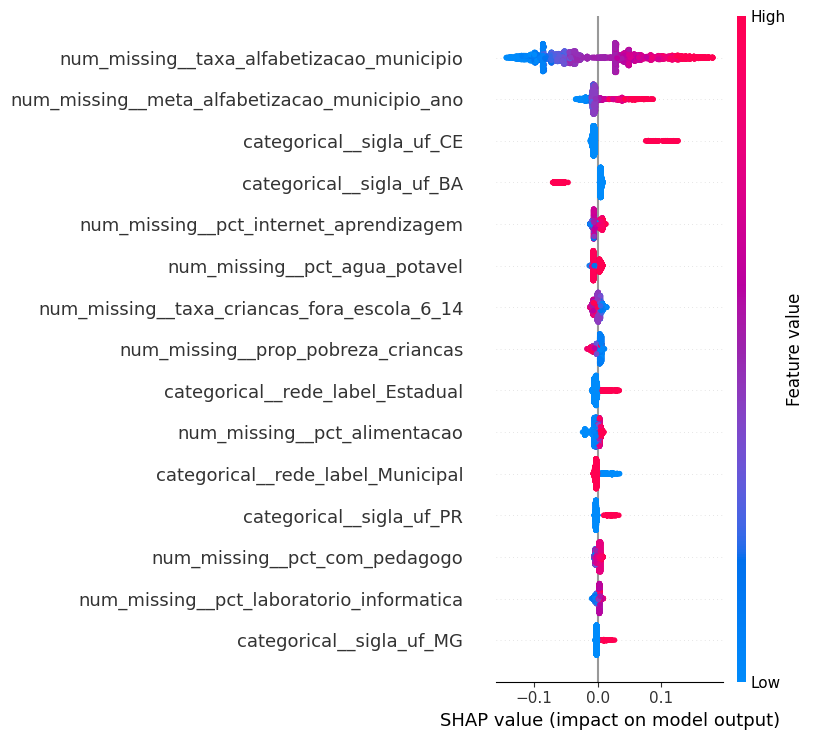

In [4]:
shap_values_alfabetizado = shap_values[:, :, 1]

shap.summary_plot(shap_values_alfabetizado, X_sample, feature_names=feature_names, max_display=15, show=True)

In [ ]:
## Conclusão: o modelo "redescobriu" os achados da EDA sozinho

O SHAP confirma, de forma independente, tudo que a análise exploratória
já tinha revelado: o contexto municipal (`taxa_alfabetizacao_municipio`)
domina a predição; Ceará se destaca como um outlier positivo isolado
(Paic); Bahia como outlier negativo; rede Estadual supera rede Municipal.
Isso é uma validação cruzada importante — o modelo não está aprendendo
ruído, está capturando os mesmos padrões estruturais e territoriais
reais que identificamos manualmente.

**Resposta à pergunta de negócio "quais variáveis mais influenciam a
alfabetização?":** primariamente o **contexto territorial agregado**
(taxa e meta do próprio município) e a **UF** — com destaque para Ceará
como case de sucesso replicável. As variáveis de enriquecimento
(infraestrutura escolar, IDHM, pobreza) contribuem sinal real, mas
secundário e parcialmente redundante com o contexto municipal já
presente na base original.